Auditory model classification demo
==================================
***An introduction to auditory modeling and machine learning in PyTorch***

<a href="https://colab.research.google.com/github/msaddler/auditory_machine_learning/blob/main/DEMO_CLASSIFICATION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Setup

Import standard Python packages.

In [ ]:
import IPython.display as ipd
import matplotlib.pyplot as plt
import numpy as np
import torch
import tqdm


If running this notebook in Google Colab, run the bash script below to clone the [**`auditory_machine_learning`**](https://github.com/msaddler/auditory_machine_learning) repository and set the working directory.

In [ ]:
!git clone https://github.com/msaddler/auditory_machine_learning.git
%cd auditory_machine_learning
!ls -1


Import [**example_datasets.py**](https://github.com/msaddler/auditory_machine_learning/blob/main/example_datasets.py), [**modules.py**](https://github.com/msaddler/auditory_machine_learning/blob/main/modules.py), and [**utils.py**](https://github.com/msaddler/auditory_machine_learning/blob/main/utils.py) as Python modules. The classes and functions in these files can then be called from this notebook.

In [ ]:
import example_datasets
import modules
import utils


Check if a GPU is available in the current runtime and define the `device` variable.

In [ ]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Available device: {device}")


Available device: cpu


## Introduction

This repository includes two small audio datsets, which can be loaded and played in the notebook.

In [ ]:
# Dataset of synthetic vowel sounds
vowel_dataset = example_datasets.SyntheticVowels(
    sr=20000,   # Sampling rate in Hz
    dur=0.250,  # Stimulus duration in s
    dbspl=60,   # Stimulus level in dB SPL
    f0=100,     # Fundamental frequency in Hz
)

example = vowel_dataset[0]
print("Indexing into `vowel_dataset` yields a dictionary with key-value pairs:")
for k, v in example.items():
    print(f"|__ {k}: {v}")
print("The `signal` is the sound waveform in Pa sampled at `sr` Hz\n")

# Iterate over the dataset and play example vowels
for itr in range(10):
    example = vowel_dataset[itr]
    sr = example["sr"]
    x = example["signal"]
    print(f'{example["vowel"]}  |  {example["vowel_str"]}  |  f0 = {example["f0"]}Hz')
    ipd.display(ipd.Audio(rate=sr, data=x))


Indexing into `vowel_dataset` yields a dictionary with key-value pairs:
|__ sr: 20000
|__ signal: [-0.00250571 -0.00250571 -0.00250571 ... -0.00250366 -0.00250534
 -0.00250571]
|__ dbspl: 60.0
|__ f0: 100.0
|__ formants: [ 325 2900 3500]
|__ vowel: 0
|__ vowel_str: /i/ (heed)
The `signal` is the sound waveform in Pa sampled at `sr` Hz

0  |  /i/ (heed)  |  f0 = 100.0Hz


1  |  /I/ (hid)  |  f0 = 100.0Hz


2  |  /e/ (hayed)  |  f0 = 100.0Hz


3  |  /eps/ (head)  |  f0 = 100.0Hz


4  |  /ae/ (had)  |  f0 = 100.0Hz


5  |  /a/ (hod)  |  f0 = 100.0Hz


6  |  /^/ (hud)  |  f0 = 100.0Hz


7  |  /o/ (hoed)  |  f0 = 100.0Hz


8  |  /U/ (hood)  |  f0 = 100.0Hz


9  |  /u/ (who'd)  |  f0 = 100.0Hz


## Cochlear model

The [**`modules`**](https://github.com/msaddler/auditory_machine_learning/blob/main/modules.py) file contains a `CochlearModel` class, which implements a simple cochlear model as a PyTorch module.

We can call this class to construct the PyTorch model object and inspect it.


In [ ]:
cochlear_model = modules.CochlearModel(
    sr_input=20000,                     # Sampling rate of input audio (Hz)
    sr_output=10000,                    # Sampling rate of output auditory nerve representations (Hz)
    fir_dur=0.05,                       # Cochlear filterbank FIR duration (s)
    cfs=utils.erbspace(8e1, 8e3, 100),  # Characteristic frequencies (Hz)
    bw_mult=1.0,                        # Scaling factor to broaden/narrow bandwidths of cochlear filters
    ihc_lowpass_cutoff=3000,            # Inner hair cell lowpass filter cutoff determines phase locking limit (Hz)
    ihc_lowpass_order=7,                # Inner hair cell lowpass filter order (int)
    threshold=0.0,                      # Absolute threshold of auditory nerve fibers (dB SPL)
    dynamic_range=80.0,                 # Dynamic range of auditory nerve fibers (dB)
    dtype=torch.float32,                # Default PyTorch datatype
)
print(cochlear_model)


CochlearModel(
  (cochlear_filterbank): GammatoneFilterbank()
  (half_wave_rectification): ReLU()
  (ihc_lowpass_filter): IHCLowpassFilter()
  (rate_level_function): SigmoidRateLevelFunction()
)


The `cochlear_model` object can be called on an input sound waveform to generate a simulated auditory nerve representation.

The [**`utils`**](https://github.com/msaddler/auditory_machine_learning/blob/main/utils.py) file contains helper functions like `make_nervegram_plot`, which we can use to visualize the simulated nerve representation.

/Users/marksa/Desktop/auditory_machine_learning/auditory_machine_learning/utils.py:152: RuntimeWarning: divide by zero encountered in log10
  pxx = 10.0 * np.log10(pxx / np.square(p_ref))


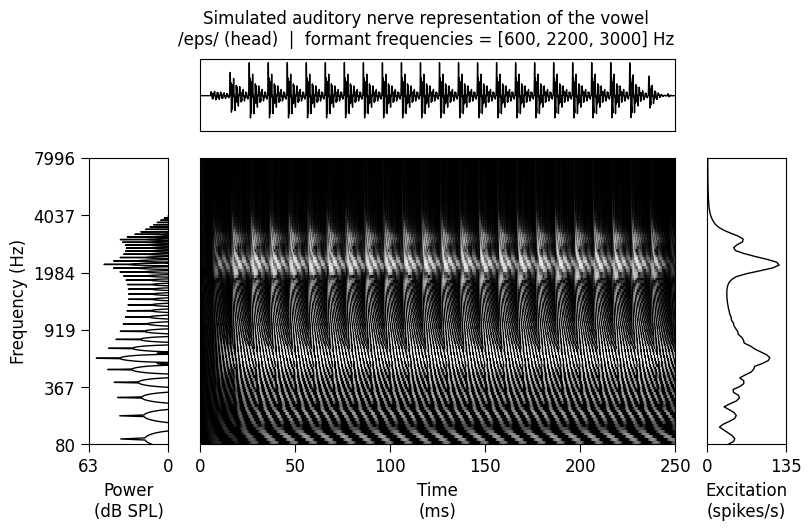

In [34]:
example = vowel_dataset[3]
# example = vowel_dataset[np.random.randint(len(vowel_dataset))]
waveform = torch.as_tensor(example["signal"])  # <-- converts a NumPy array to a PyTorch tensor 
nervegram = cochlear_model(waveform)

fig, ax_arr = utils.make_nervegram_plot(
    waveform=waveform.numpy(),  # <-- .numpy() converts a PyTorch tensor back to a NumPy array
    nervegram=nervegram.numpy(),
    sr_waveform=cochlear_model.sr_input,
    sr_nervegram=cochlear_model.sr_output,
    cfs=cochlear_model.cfs,
)
s = f"{example['vowel_str']}  |  formant frequencies = {[int(_) for _ in example['formants']]} Hz"
fig.suptitle(f"Simulated auditory nerve representation of the vowel\n{s}")
plt.show()


The following cell visualizes the input-output functions of each stage of the simplistic cochlear model.

/Users/marksa/Desktop/auditory_machine_learning/auditory_machine_learning/utils.py:152: RuntimeWarning: divide by zero encountered in log10
  pxx = 10.0 * np.log10(pxx / np.square(p_ref))


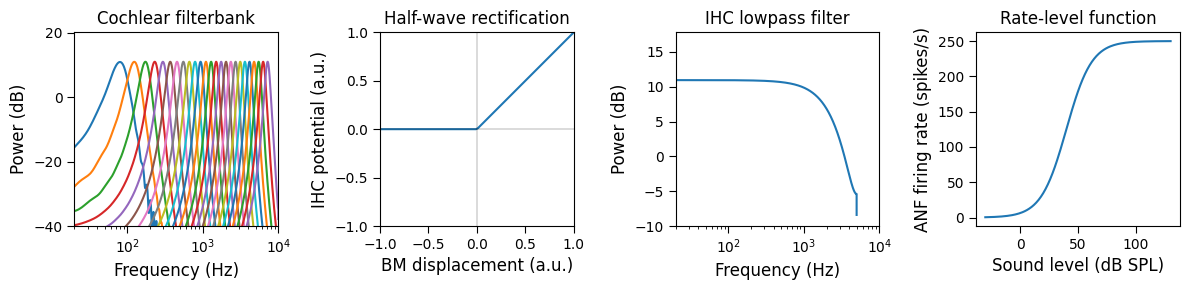

In [35]:
fig, ax_arr = plt.subplots(nrows=1, ncols=4, figsize=(12, 3))

impulse = torch.zeros(int(cochlear_model.sr_input))
impulse[0] = 1

# Plot frequency response of cochlear filterbank (linear Gammatone filterbank)
cochlear_filterbank_impulse_response = cochlear_model.cochlear_filterbank(impulse)
fxx, pxx = utils.periodogram(
    cochlear_filterbank_impulse_response.numpy(),
    cochlear_model.sr_input,
)
ax_arr[0].plot(fxx, pxx[::4].T)
ax_arr[0] = utils.format_axes(
    ax_arr[0],
    str_title="Cochlear filterbank",
    str_xlabel="Frequency (Hz)",
    str_ylabel="Power (dB)",
    xscale="log",
    xlimits=[20, cochlear_model.sr_input // 2],
    ylimits=[-40, None],
    fontsize_ticks=10,
)

# Plot IHC transduction function (crudely modeled as half-wave rectification)
x = torch.linspace(-1, 1, 100)
y = cochlear_model.half_wave_rectification(x)
ax_arr[1].plot(x.numpy(), y.numpy())
ax_arr[1].axvline(0, color="k", lw=0.2)
ax_arr[1].axhline(0, color="k", lw=0.2)
ax_arr[1].axis("square")
ax_arr[1] = utils.format_axes(
    ax_arr[1],
    xlimits=[-1, 1],
    ylimits=[-1, 1],
    str_xlabel="BM displacement (a.u.)",
    str_ylabel="IHC potential (a.u.)",
    str_title="Half-wave rectification",
    fontsize_ticks=10,
)

# Plot frequency response of IHC lowpass filter (sets upper limit of phase locking)
ihc_lowpass_filter_impulse_response = cochlear_model.ihc_lowpass_filter(impulse)
fxx, pxx = utils.periodogram(
    ihc_lowpass_filter_impulse_response.numpy(),
    cochlear_model.sr_output,
)
ax_arr[2].plot(fxx, pxx)
ax_arr[2] = utils.format_axes(
    ax_arr[2],
    str_title="IHC lowpass filter",
    str_xlabel="Frequency (Hz)",
    str_ylabel="Power (dB)",
    xscale="log",
    xlimits=[20, cochlear_model.sr_input // 2],
    ylimits=[-10, None],
    fontsize_ticks=10,
)

# Plot auditory nerve rate-level function (determines threshold and dynamic range)
x_db = torch.arange(-30, 131)
x_pa = 20e-6 * (10 ** (x_db / 20))
y = cochlear_model.rate_level_function(x_pa)
ax_arr[3].plot(x_db.numpy(), y.numpy())
ax_arr[3] = utils.format_axes(
    ax_arr[3],
    str_xlabel="Sound level (dB SPL)",
    str_ylabel="ANF firing rate (spikes/s)",
    str_title="Rate-level function",
    fontsize_ticks=10,
)

plt.tight_layout()
plt.show()


To get a better sense of the cochlear model, we can successively apply each model stage to an input sound and plot the output after each stage.

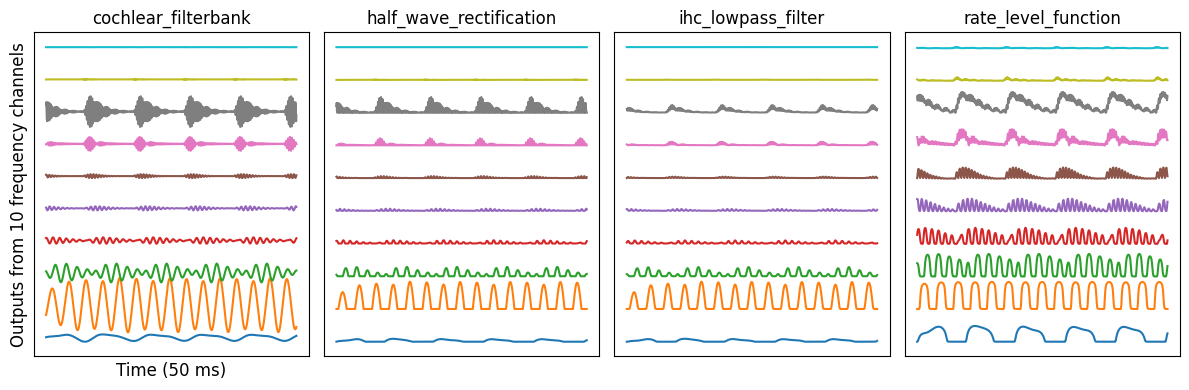

In [36]:
example = vowel_dataset[0]
x = torch.as_tensor(example["signal"])

list_model_stage_name = [
    "cochlear_filterbank",
    "half_wave_rectification",
    "ihc_lowpass_filter",
    "rate_level_function",
]

# Iteratively apply cochlear model stages and visualize output after each stage
fig, ax_arr = plt.subplots(nrows=1, ncols=len(list_model_stage_name), figsize=(12, 4))
for itr_ax, model_stage_name in enumerate(list_model_stage_name):
    model_stage = getattr(cochlear_model, model_stage_name)
    x = model_stage(x)

    # Plot only a handful of the model frequency channels
    # (excerpted and peak-normalized for visualization)
    sr = cochlear_model.sr_input if itr_ax < 2 else cochlear_model.sr_output
    t0 = 0.025
    t1 = 0.075
    excerpt = slice(int(sr * t0), int(sr * t1))
    x_to_show = x[5::10, excerpt].numpy()
    x_to_show = x_to_show / np.max(x_to_show)

    ax = ax_arr[itr_ax]
    for itr_channel in range(x_to_show.shape[0]):
        ax.plot(x_to_show[itr_channel] + 1.2 * itr_channel)
    ax = utils.format_axes(
        ax,
        str_title=model_stage_name,
        xticks=[],
        yticks=[],
        str_xlabel=f"Time ({(t1 - t0) * 1e3:.0f} ms)" if itr_ax == 0 else None,
        str_ylabel=f"Outputs from {x_to_show.shape[0]} frequency channels" if itr_ax == 0 else None,
    )
plt.tight_layout()
plt.show()
